## **SUMMARY**
This script is used to create an inventory using raw NSI point data spatially joined using intersection with footprint data. Steps include the spatial join, inferring structure type and exporting in an R2D-Compatible format. 



In [1]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [2]:
# Relevant python functions
import pandas as pd
import geopandas as gpd
import random
import matplotlib.pyplot as plt
import folium 
import os
import sys
import matplotlib.patches as mpatches

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_preprocessing as pre
import functions_disagreement_and_gaps as resolve

In [3]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

In [4]:
# Select Footprint Source
footprint_path = './Input_Data/ProcessedFootprints/Hayward_Footprints.json'
footprints = gpd.read_file(footprint_path)
footprints.to_crs(crs_main, inplace = True)

In [5]:
# Create Output Directory
name = 'NSI_SpatialJoin' # This will be the name of the inventory within the R2D folder
dir_r2d = './R2D_Analysis/Inventories/' + name + '/'
os.makedirs(dir_r2d, exist_ok=True)

### **Filter Raw NSI Data and Rename Columns**

Original eplacement cost (ten billions): 444
For consistency with 2022, modified replacement cost to be structure + content (ten billions): 651


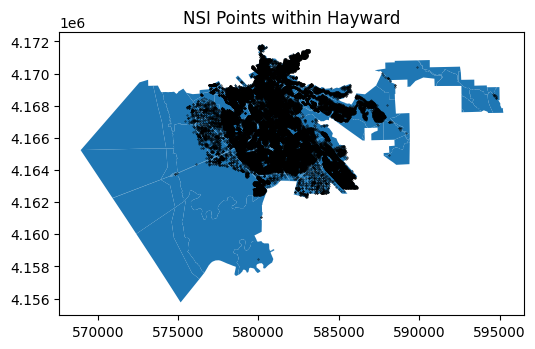

In [6]:
##### LOAD NSI DATA DOWNLOADED USING BRAILS TOOL AND CONVERT TO APPROPRIATE CRS #####
nsi = gpd.read_file('./Input_Data/National/06001.gpkg')
nsi = nsi.to_crs(epsg=crs_main)

# ##### RENAME AND DROP NSI COLUMNS AS APPROPRIATE #####
# # Note - if different columns present in the nsi dataframe than in the case of Hayward, go to the 
# # rename_nsi_data26 function and comment out / add appropriate column names as needed 
nsi = pre.rename_nsi_data26(nsi.copy())

##### CHECK AND ASSIGN CENSUS BLOCK INFORMATION FOR NSI DATA #####
# Load Census blocks and tracts 
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2020/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2020/Hayward_tracts.geojson')

# # Merge NSI data with City-Specific Census Blocks and check for errors in NSI data
nsi = nsi[nsi['CensusBlock'].isin(hayward_blocks['GEOID20'].to_list())].copy()

# Plot Results
fig, ax = plt.subplots(1,1, figsize = (6, 6))
hayward_blocks.plot(ax=ax)
nsi.plot(ax=ax, color ='black', markersize = 0.1)
ax.set_title('NSI Points within Hayward')
plt.show()

### **Spatially Join Data**

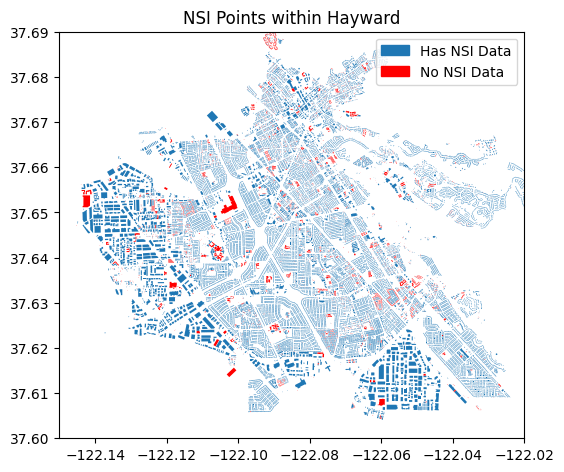

In [7]:
# Spatially Join Footprints and Raw NSI 
joined = footprints.sjoin(nsi, how='left')
joined = joined.drop_duplicates(subset=['FootprintID'], keep='first')

# Maintain for plotting later on
has_data_ftpt = joined[joined['NSI_OccupancyClass'].notna()]
no_data_ftpt = joined[joined['NSI_OccupancyClass'].isna()]

# Plot Results
fig, ax = plt.subplots(1,1, figsize = (6, 6))
joined[joined['NSI_OccupancyClass'].notna()].copy().to_crs(crs_plot).plot(ax=ax, markersize = 0.1)
joined[joined['NSI_OccupancyClass'].isna()].copy().to_crs(crs_plot).plot(ax=ax, markersize = 0.1, color = 'red')
ax.set_title('NSI Points within Hayward')
handles = [
    mpatches.Patch(color='tab:blue', label='Has NSI Data'),
    mpatches.Patch(color='red', label='No NSI Data')]
ax.legend(handles=handles)
ax.set_xlim(xbounds)
ax.set_ylim(ybounds)
plt.show()

# Modify footprint inventory geometry to be the centroid of each footprint 
joined = joined.rename(columns={'geometry': 'ftpt_geometry'})
joined['geometry'] = joined['ftpt_geometry'].centroid
joined.set_geometry('geometry')

# Remove footprints that have no NSI data
has_data = joined[joined['NSI_OccupancyClass'].notna()]
no_data = joined[joined['NSI_OccupancyClass'].isna()]


### **Infer Structure Type**

In [8]:
# SET FLAG 
use_bldg_type = True # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = False # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = False # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = False # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# SET VARIABLE NAMES
state = 'California'
occ_key = 'NSI_OccupancyClass'
nstory_key = 'NSI_NumberOfStories'
year_key = 'NSI_MedYearBuilt'
strtype_key = 'StructureType'
bldgtype_key = 'NSI_BuildingType'
n_pw = 1

# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(has_data.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)


CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-COM1-mid_rise-post_1970-W
Num Buildings in that Class: 1
1 HAZUS does not provide structural type information for West Coast-RES1-low_rise-1950_to_1970-California-C
Num Buildings in that Class: 21
1 HAZUS does not provide structural type information for West Coast-RES1-low_rise-post_1970-California-C
Num Buildings in that Class: 12
HAZUS does not provide structural type information for West Coast-COM7-high_rise-1950_to_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-post_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-1950_to_1970-S
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-RES3-mid_rise-1950_to_1970-W
Num Buildings in that Class: 4
HAZUS does not provide str

In [9]:
## REPEAT INFER PROCESS AND REMOVE BUILDING TYPES THAT ARE MISSING HAZUS FRAGILITY FUNCTIONS 

# Load best estimate inventory 
alldata = bldg_properties_df.copy()


missing_structuretype = alldata[((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()
has_structuretype = alldata[~((alldata['StructureType'].isna()) | (alldata['StructureType']=='na'))].copy()

# Check if any data lost
if len(missing_structuretype) + len(has_structuretype) != len(alldata):
    raise ValueError('Data Lost')

# SET FLAG 
use_bldg_type = False # Use building type (material) to constrain list of possible structure types  
allow_mh_only_for_res2 = False # Allows structure type 'MH' only when the occupancy class is RES2 (diverges from Hazus) 
no_urm = False # Doesn't allow the assignment of URM buildings, due to efforts to retrofit those buildings (diverges from Hazus)
res3ab_to_res1_flag = False # Adopts structure types used for 'RES1' to be assigned for RES3A and RES3B. 2-4 unit structures are likely structurally more similar to single family homes than to large apartment buildings. 


# CALL FUNCTION TO INFER STRUCTURE TYPE
bldg_properties_df = resolve.infer_structure_type(missing_structuretype.copy(), state, occ_key, nstory_key, year_key, bldgtype_key, strtype_key, n_pw, use_bldg_type, allow_mh_only_for_res2, no_urm, res3ab_to_res1_flag)

# Recombine dataframes 
recombined_gdf = gpd.GeoDataFrame(pd.concat([has_structuretype, bldg_properties_df], ignore_index=True))

# Check if any data lost
if len(recombined_gdf) != len(alldata):
    raise ValueError('Data Lost')


# Fill errors in structure type if desired
fill_in_error_structure_types = True
recombined_gdf = resolve.resolve_structure_errors(recombined_gdf.copy(), fill_in_error_structure_types)


CHECK: Regions considered in structure type assignment: ['West Coast']
HAZUS does not provide structural type information for West Coast-EDU1-mid_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM8-high_rise-post_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-1950_to_1970
Num Buildings in that Class: 1
HAZUS does not provide structural type information for West Coast-COM7-high_rise-post_1970
Num Buildings in that Class: 1
0 points dropped due to missing structure type


### **Export for R2D**


In [10]:
# Compute plan area 
recombined_gdf['NSI_PlanAreaSqFt'] = recombined_gdf['NSI_TotalAreaSqFt'] / recombined_gdf['NSI_NumberOfStories']

# Create appropriate columns
r2d = recombined_gdf.copy().to_crs('EPSG:4269')
r2d['Longitude'] = r2d['geometry'].x
r2d['Latitude'] = r2d['geometry'].y
r2d = r2d[['Latitude','Longitude','NSI_PlanAreaSqFt','NSI_NumberOfStories','NSI_MedYearBuilt','NSI_BuildingType','NSI_ReplacementCost','StructureType','NSI_OccupancyClass','NSI_OccupancyClass_clean','NSI_Population_Night','FootprintID','geometry']]

# Rename columns for R2D use
r2d = r2d.rename(columns={'NSI_OccupancyClass': 'OccupancyClass_Actual'})
r2d = r2d.rename(columns={'NSI_OccupancyClass_clean': 'OccupancyClass'})
r2d = r2d.rename(columns={'NSI_NumberOfStories': 'NumberOfStories',
                          'NSI_PlanAreaSqFt':'PlanArea',
                          'NSI_MedYearBuilt':'YearBuilt',
                          'NSI_BuildingType': 'BuildingType',
                          'NSI_Population_Night':'NightPopulation',
                          'NSI_ReplacementCost':'ReplacementCost'})

# Update building type based on structure type assignment 
r2d['BuildingType'] = r2d['StructureType'].apply(resolve.extract_bldg_type)

# Assign design level and height class (used in regional analysis)
r2d = resolve.find_design_level(r2d, 'StructureType', 'YearBuilt', 'DesignLevel')
r2d = resolve.find_height_class(r2d, 'StructureType', 'NumberOfStories', 'HeightClass')

# Add id
r2d.insert(0, 'id', range(len(r2d)))

# Save inventory
r2d.to_csv(dir_r2d + 'R2D_Inventory.csv', index = False)
fxns.gdf_to_json(r2d, dir_r2d + 'R2D_Inventory.json')

# Randomly sample for R2D test run 
sampled_df = r2d.sample(n=50, random_state=1, replace = False)
sampled_df = sampled_df.drop(columns='id')
sampled_df.insert(0, 'id', range(len(sampled_df)))
sampled_df.to_csv(dir_r2d + 'R2D_Inventory_SAMPLED.csv', index = False)


JSON File Saved


In [11]:
# ### PLOT USED/UNUSED FOOTPRINTS AND USED/UNUSED POINTS

# used_nsi_id = list(has_data['NSI_fdid'])
# used_nsi = nsi[nsi['NSI_fdid'].isin(used_nsi_id)]
# not_used_nsi = nsi[~nsi['NSI_fdid'].isin(used_nsi_id)]


# fig, ax = plt.subplots(1,1)
# no_data_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = 'red')
# has_data_ftpt.copy().to_crs(crs_plot).plot(ax=ax, color = 'gray')
# plt.show()

# fig, ax = plt.subplots(1,1)
# used_nsi.copy().to_crs(crs_plot).plot(ax=ax, markersize = 0.05, color = 'gray')
# not_used_nsi.copy().to_crs(crs_plot).plot(ax=ax, markersize = 0.05, color = 'red')
# plt.show()